# TransformerQEC: Transformer Decoder & Training

Define and train a transformer-based neural decoder for surface code quantum error correction using JAX / Flax.

**Architecture:** Pre-norm transformer encoder with CLS-token classification and physical error rate conditioning (analogous to timestep conditioning in diffusion models).

In [ ]:
# Install pinned deps from repo requirements.txt (Drive-mounted path).
# If requirements.txt isn't reachable yet (fresh Colab), fall back to inline pins.
import os
_REQ_PATH = '/content/drive/MyDrive/TransformerQEC/requirements.txt'
if os.path.exists(_REQ_PATH):
    !pip install -q -r {_REQ_PATH}
else:
    !pip install -q "stim>=1.14,<2" "pymatching>=2,<3" "flax>=0.8" optax "numpy<2"

In [13]:
import jax
import jax.numpy as jnp
import flax.linen as nn
from flax.training.train_state import TrainState
import optax
import numpy as np
import stim
import matplotlib.pyplot as plt
import pickle
import os
import time

print(f'JAX backend: {jax.default_backend()}')
print(f'JAX devices: {jax.devices()}')

JAX backend: tpu
JAX devices: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]


## Data Generation

In [ ]:
def make_circuit(d, p, rounds=None):
    if rounds is None:
        rounds = d
    return stim.Circuit.generated(
        "surface_code:rotated_memory_z",
        distance=d, rounds=rounds,
        before_round_data_depolarization=p,
        before_measure_flip_probability=p,
    )


def sample_syndromes(circuit, num_shots):
    sampler = circuit.compile_detector_sampler()
    det, obs = sampler.sample(num_shots, separate_observables=True)
    return det.astype(np.float32), obs[:, 0].astype(np.int64)


def get_detector_coords(d, rounds=None):
    """Extract raw integer detector (x, y, round) coordinates (DIPE).

    Returns: np.ndarray of shape (num_detectors, 3), float32.
    Each axis is origin-shifted so it starts at 0 — but NOT normalized
    or rescaled. The same physical lattice cell yields the same coord
    value across code distances, which is the property that makes
    DIPE-form RoPE distance-invariant.
    """
    circuit = make_circuit(d, p=0.01, rounds=rounds)  # p doesn't affect coords
    raw = circuit.get_detector_coordinates()
    num_det = circuit.num_detectors
    coords = np.zeros((num_det, 3), dtype=np.float32)
    for det_idx, c in raw.items():
        coords[det_idx] = c[:3]
    for axis in range(3):
        coords[:, axis] = coords[:, axis] - coords[:, axis].min()
    return coords


def build_samplers(d, p_values, rounds=None):
    """Cache one stim.CompiledDetectorSampler per p value.

    Rebuilding the circuit + compiling the sampler each step would dominate
    training time. On-the-fly sampling uses these cached objects; per-step
    cost becomes pure sampling (fast: <5ms for 1024 shots at d=5).
    """
    samplers = {}
    for p in p_values:
        circuit = make_circuit(d, p, rounds=rounds)
        samplers[float(p)] = circuit.compile_detector_sampler()
    return samplers


def sample_batch(sampler, batch_size, p_val):
    """Sample one training batch from a cached sampler.

    Returns (syn, lab, pe) as numpy arrays shaped (B, L), (B,), (B,).
    """
    det, obs = sampler.sample(batch_size, separate_observables=True)
    syn = det.astype(np.float32)
    lab = obs[:, 0].astype(np.int64)
    pe = np.full(batch_size, p_val, dtype=np.float32)
    return syn, lab, pe


def generate_val_dataset(d, p_values, shots_per_p):
    """Bulk-materialize a validation dataset.

    Val set is kept deterministic + stable across training runs so val_loss
    curves are directly comparable.  Training data is generated on-the-fly
    (see `sample_batch` + `build_samplers`).
    """
    all_syn, all_lab, all_p = [], [], []
    for p in p_values:
        syn, lab = sample_syndromes(make_circuit(d, p), shots_per_p)
        all_syn.append(syn)
        all_lab.append(lab)
        all_p.append(np.full(shots_per_p, p, dtype=np.float32))
    coords = get_detector_coords(d)
    return (np.concatenate(all_syn), np.concatenate(all_lab),
            np.concatenate(all_p), coords)


def build_p_schedule(p_values, cycle_len=5000, weight_exponent=0.5, rng_seed=0):
    """Deterministic pre-shuffled p-value schedule, weighted 1/p**weight_exponent.

    Low-p bins (where label-1 is rare at ~10^-4) get oversampled — free
    stratification subsuming FIX 9.  Exponent 0.5 ≈ 1/sqrt(p); 1.0 = inverse p.
    """
    p_arr = np.asarray(p_values, dtype=np.float64)
    weights = p_arr ** (-weight_exponent)
    weights = weights / weights.sum()
    # Integer counts per p that sum to cycle_len
    counts = np.round(weights * cycle_len).astype(int)
    # Adjust last bin so counts sum exactly to cycle_len
    counts[-1] += cycle_len - int(counts.sum())
    schedule = np.concatenate([
        np.full(c, p, dtype=np.float32) for p, c in zip(p_arr, counts) if c > 0
    ])
    rng = np.random.default_rng(rng_seed)
    rng.shuffle(schedule)
    return schedule

## Model Architecture

Pre-norm transformer encoder with:
- **Token embedding:** each binary detection event $\rightarrow$ $d_{\text{model}}$-dim vector
- **(2+1)D RoPE (DIPE form):** raw integer detector (x, y, round) coordinates, no per-distance rescaling — same physical lattice cell yields the same rotation angle across $d$
- **Maskless attention:** full dense $\mathcal{O}(L^2)$ self-attention (prior locality mask removed; see `STATE.md` Cycle A)
- **CLS token:** aggregates global context for classification
- **Error rate conditioning:** physical error rate $p$ broadcast-added to all tokens
- **Gradient checkpointing (`nn.remat`):** recomputes block activations during backprop instead of storing all layers — reduces peak activation memory to $\mathcal{O}(1/\sqrt{N_{\text{layers}}})$ at ~30% compute cost. Forward output bit-identical; needed to fit $d=7$ ($L=337$) and enable $d=9$ training.

In [ ]:
# Single source of truth for model architecture: notebooks/model.py.
# Mount Drive and import TransformerQEC from there so train + eval cannot drift.
import sys
from google.colab import drive
drive.mount('/content/drive')

FOLDER_PATH = '/content/drive/MyDrive/TransformerQEC/notebooks'
if FOLDER_PATH not in sys.path:
    sys.path.append(FOLDER_PATH)

from model import TransformerQEC

## Training Setup

In [ ]:
def focal_loss(logits, labels, num_classes=2, gamma=2.0, alpha=0.75):
    """Focal loss for class-imbalanced binary classification.

    Logical errors are ~0.02-0.2% of samples at low physical error rates,
    so standard cross-entropy gradient is dominated by the overwhelming
    majority of easy "no flip" examples. Focal loss down-weights
    well-classified examples by (1 - p_t)^gamma, letting the model
    focus on hard/rare positive cases. alpha weights the rare positive
    class more heavily.
    """
    probs = jax.nn.softmax(logits)
    one_hot = jax.nn.one_hot(labels, num_classes)
    # p_t: probability assigned to the correct class
    p_t = (probs * one_hot).sum(-1)
    # alpha_t: alpha for positive (flip) examples, (1-alpha) for negative
    alpha_t = alpha * labels + (1.0 - alpha) * (1 - labels)
    focal_weight = (1.0 - p_t) ** gamma
    loss = -alpha_t * focal_weight * jnp.log(p_t + 1e-8)
    return loss.mean()


def create_train_state(key, model, seq_len, coords, num_steps, warmup_steps=2000, peak_lr=1e-4):
    dummy_syn = jnp.zeros((1, seq_len))
    dummy_p = jnp.zeros((1,))
    params = model.init(key, dummy_syn, dummy_p, coords)["params"]

    # Clamp warmup so cosine decay portion is always positive
    warmup_steps = min(warmup_steps, num_steps // 5)

    schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0, peak_value=peak_lr,
        warmup_steps=warmup_steps,
        decay_steps=num_steps, end_value=5*1e-7)

    # Muon optimizer: Newton-Schulz preconditioned SGD on 2D params (Dense
    # kernels), AdamW on 1D params (biases, LayerNorm scales).
    # adam_learning_rate = 20% of peak for the AdamW fallback path.
    muon_adam_schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0, peak_value=peak_lr * 0.2,
        warmup_steps=warmup_steps,
        decay_steps=num_steps, end_value=1e-6 * 0.2)
    tx = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.contrib.muon(
            learning_rate=schedule,
            adam_learning_rate=muon_adam_schedule,
            weight_decay=0.1))
    return TrainState.create(apply_fn=model.apply, params=params, tx=tx)


def make_train_fns(model, coords_d):
    """Build chunk-based training step + scan-based eval.

    Training data is generated on-the-fly: Python loop produces
    CHUNK_SIZE batches worth of (syn, lab, pe) per call, device_puts to
    TPU, then `train_chunk` runs `jax.lax.scan` across the chunk so we
    retain scan throughput (amortized JIT dispatch, compiled XLA loop).

    Validation is still bulk-materialized + scanned as before.
    """

    @jax.jit
    def train_chunk(state, chunk_syn, chunk_lab, chunk_pe):
        """chunk_*: (CHUNK_SIZE, BATCH_SIZE, ...). Runs CHUNK_SIZE grad steps."""
        def body(state, batch):
            syn, lab, pe = batch
            def loss_fn(params):
                logits = model.apply({"params": params}, syn, pe, coords_d)
                return focal_loss(logits, lab), logits
            (loss, logits), grads = jax.value_and_grad(
                loss_fn, has_aux=True)(state.params)
            state = state.apply_gradients(grads=grads)
            acc = (logits.argmax(-1) == lab).mean()
            return state, (loss, acc)
        state, (losses, accs) = jax.lax.scan(
            body, state, (chunk_syn, chunk_lab, chunk_pe))
        return state, losses.mean(), accs.mean()

    @jax.jit
    def eval_epoch(params, batches):
        """Validation sweep as one compiled XLA while-loop (bulk val set)."""
        def body(metrics, batch):
            loss_sum, acc_sum = metrics
            syn, lab, pe = batch
            logits = model.apply({"params": params}, syn, pe, coords_d)
            loss = focal_loss(logits, lab)
            acc = (logits.argmax(-1) == lab).mean()
            return (loss_sum + loss, acc_sum + acc), None
        n = batches[0].shape[0]
        (total_loss, total_acc), _ = jax.lax.scan(
            body, (jnp.float32(0.0), jnp.float32(0.0)), batches)
        return total_loss / n, total_acc / n

    return train_chunk, eval_epoch

## Generate Data & Initialize Model

In [ ]:
# --- Configuration ---
DISTANCE = 5
NUM_P = 20
BATCH_SIZE = 1024
CHUNK_SIZE = 100                # batches per scan-based train_chunk call
STEPS_PER_EPOCH = 5859          # matches prior bulk-pipeline compute budget
NUM_EPOCHS = 13
VAL_SHOTS_PER_P = 15_000        # 15k * 20 p-values = 300k val samples
P_TRAIN = np.geomspace(0.002, 0.017, NUM_P).tolist()
SEED = 42

# Derived
CHUNKS_PER_EPOCH = STEPS_PER_EPOCH // CHUNK_SIZE   # = 58 at 5859/100
EFFECTIVE_STEPS_PER_EPOCH = CHUNKS_PER_EPOCH * CHUNK_SIZE
TOTAL_STEPS = EFFECTIVE_STEPS_PER_EPOCH * NUM_EPOCHS

print(f'Training: on-the-fly STIM sampling (chunk_size={CHUNK_SIZE})')
print(f'Error rates ({NUM_P} geomspace): {[f"{p:.4f}" for p in P_TRAIN]}')

# Build cached samplers once — reused across all 76k+ training steps.
print('Building STIM samplers (one per p value)...')
samplers = build_samplers(DISTANCE, P_TRAIN)

# Deterministic p-schedule weighted ~ 1/sqrt(p) — oversamples low-p bins
# (subsumes FIX 9 stratified-sampling since rare-label p values get more
# step budget without changing the loss function).
p_schedule = build_p_schedule(P_TRAIN, cycle_len=10_000,
                              weight_exponent=0.5, rng_seed=SEED)
print(f'p-schedule: cycle_len={len(p_schedule)}, '
      f'unique p-values={len(set(p_schedule.tolist()))}, '
      f'low-p oversample ratio '
      f'({P_TRAIN[0]:.4f}/{P_TRAIN[-1]:.4f}) = '
      f'{(p_schedule == np.float32(P_TRAIN[0])).sum() / max((p_schedule == np.float32(P_TRAIN[-1])).sum(), 1):.2f}x')

# Materialize validation set (stable, deterministic — gives comparable
# val_loss across runs).
print('Generating validation dataset...')
val_syn, val_lab, val_p, coords = generate_val_dataset(
    DISTANCE, P_TRAIN, VAL_SHOTS_PER_P)
print(f'Val:   {val_syn.shape[0]:,} samples, seq_len={val_syn.shape[1]}, '
      f'error_rate={val_lab.mean():.3f}')
print(f'Coords: {coords.shape} (raw integer detector positions, '
      f'max per-axis: {coords.max(axis=0).tolist()})')
print(f'Total training steps: {TOTAL_STEPS:,} '
      f'({NUM_EPOCHS} epochs × {EFFECTIVE_STEPS_PER_EPOCH} steps/epoch '
      f'× {BATCH_SIZE} batch → {TOTAL_STEPS * BATCH_SIZE:,} distinct samples)')

In [ ]:
# Initialize model and optimizer
seq_len = val_syn.shape[1]
model = TransformerQEC(dtype=jnp.bfloat16,
                       code_distance=DISTANCE, measurement_rounds=DISTANCE)
coords_d = jax.device_put(coords)  # Transfer coords to device once
steps_per_epoch = EFFECTIVE_STEPS_PER_EPOCH
num_steps = TOTAL_STEPS
# Warmup = 2 epochs: enough to ramp LR even with large-batch low step counts
warmup_steps = steps_per_epoch * 2
key = jax.random.PRNGKey(SEED)
state = create_train_state(key, model, seq_len, coords_d, num_steps,
                           warmup_steps=warmup_steps)
param_count = sum(p.size for p in jax.tree_util.tree_leaves(state.params))
print(f'Parameters:   {param_count:,}')
print(f'Sequence len: {seq_len}')
print(f'Batch size:   {BATCH_SIZE}')
print(f'Chunk size:   {CHUNK_SIZE} ({CHUNKS_PER_EPOCH} chunks/epoch)')
print(f'Steps/epoch:  {steps_per_epoch}')
print(f'Warmup steps: {warmup_steps}')
print(f'Total steps:  {num_steps:,}')

## Training Loop

In [ ]:
import pickle, os
from datetime import datetime

# Drive already mounted in cell-6 (import-from-model.py). Reuse that mount.
save_dir = '/content/drive/My Drive/TransformerQEC/results'
os.makedirs(save_dir, exist_ok=True)

# Per-run timestamp used in every checkpoint filename + saved config, so
# repeated runs (same distance) don't overwrite each other and each file
# is traceable back to its training session.
RUN_STAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
print(f'Run stamp: {RUN_STAMP}')

best_val_loss = float('inf')
best_params = None
best_epoch = 0
best_val_acc = 0.0

In [ ]:
import concurrent.futures

train_losses, train_accs = [], []
val_losses, val_accs = [], []

# Pre-batch validation data for scan: (n_val_batches, BATCH_SIZE, ...)
n_val = (len(val_syn) // BATCH_SIZE) * BATCH_SIZE
n_val_batches = n_val // BATCH_SIZE
val_batches = (
    jax.device_put(val_syn[:n_val]).reshape(n_val_batches, BATCH_SIZE, seq_len),
    jax.device_put(val_lab[:n_val]).reshape(n_val_batches, BATCH_SIZE),
    jax.device_put(jnp.asarray(val_p[:n_val], dtype=jnp.bfloat16)).reshape(n_val_batches, BATCH_SIZE),
)
print(f'{CHUNKS_PER_EPOCH} chunks/epoch, {n_val_batches} val batches/epoch')

train_chunk, eval_epoch = make_train_fns(model, coords_d)


def produce_chunk(step_start):
    """Generate CHUNK_SIZE training batches on CPU using cached STIM samplers.

    Picks p values from the deterministic p_schedule so each run's
    oversampling pattern is reproducible.  Returns numpy arrays of shape
    (CHUNK_SIZE, BATCH_SIZE, *).
    """
    syns = np.empty((CHUNK_SIZE, BATCH_SIZE, seq_len), dtype=np.float32)
    labs = np.empty((CHUNK_SIZE, BATCH_SIZE),          dtype=np.int64)
    pes  = np.empty((CHUNK_SIZE, BATCH_SIZE),          dtype=np.float32)
    L = len(p_schedule)
    for i in range(CHUNK_SIZE):
        p_val = float(p_schedule[(step_start + i) % L])
        sampler = samplers[p_val]
        det, obs = sampler.sample(BATCH_SIZE, separate_observables=True)
        syns[i] = det.astype(np.float32)
        labs[i] = obs[:, 0].astype(np.int64)
        pes[i].fill(p_val)
    return syns, labs, pes


def to_device(syns, labs, pes):
    return (
        jax.device_put(syns),
        jax.device_put(labs),
        jax.device_put(jnp.asarray(pes, dtype=jnp.bfloat16)),
    )


# ---- Training loop (on-the-fly) ----
executor = concurrent.futures.ThreadPoolExecutor(max_workers=1)
prev_safety_path = None
t0 = time.time()

# Warm up the prefetch pipeline with the first chunk
next_future = executor.submit(produce_chunk, 0)

global_step = 0
for epoch in range(NUM_EPOCHS):
    running_loss = running_acc = 0.0
    epoch_start = time.time()
    last_log_time = time.time()
    last_log_step = global_step

    for chunk_idx in range(CHUNKS_PER_EPOCH):
        # Pull the pre-produced chunk (blocks only if CPU hasn't caught up)
        syns, labs, pes = next_future.result()

        # Immediately kick off the NEXT chunk on CPU so it runs in parallel
        # with the upcoming TPU step.
        is_final_chunk = (epoch == NUM_EPOCHS - 1) and (chunk_idx == CHUNKS_PER_EPOCH - 1)
        if not is_final_chunk:
            next_future = executor.submit(produce_chunk, global_step + CHUNK_SIZE)

        # Device transfer + TPU training for this chunk
        chunk_syn, chunk_lab, chunk_pe = to_device(syns, labs, pes)
        state, chunk_loss, chunk_acc = train_chunk(
            state, chunk_syn, chunk_lab, chunk_pe)
        chunk_loss.block_until_ready()

        running_loss += float(chunk_loss) * CHUNK_SIZE
        running_acc  += float(chunk_acc)  * CHUNK_SIZE
        global_step += CHUNK_SIZE

        # Step-rate + recent-loss log every ~100 steps (= every chunk at CHUNK_SIZE=100)
        if (chunk_idx + 1) % max(1, 100 // CHUNK_SIZE) == 0:
            now = time.time()
            dt = max(now - last_log_time, 1e-6)
            sps = (global_step - last_log_step) / dt
            print(f'  [epoch {epoch+1} chunk {chunk_idx+1}/{CHUNKS_PER_EPOCH}] '
                  f'step {global_step}/{TOTAL_STEPS}  '
                  f'{sps:.1f} steps/s  loss={float(chunk_loss):.4f}  '
                  f'acc={float(chunk_acc):.4f}')
            last_log_time = now
            last_log_step = global_step

    train_loss = running_loss / EFFECTIVE_STEPS_PER_EPOCH
    train_acc  = running_acc  / EFFECTIVE_STEPS_PER_EPOCH
    val_loss, val_acc = eval_epoch(state.params, val_batches)
    val_acc.block_until_ready()
    elapsed = time.time() - t0

    train_losses.append(float(train_loss))
    train_accs.append(float(train_acc))
    val_losses.append(float(val_loss))
    val_accs.append(float(val_acc))
    tag = ' [incl. JIT compilation]' if epoch == 0 else ''
    print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS} | '
          f'train loss={train_losses[-1]:.4f} acc={train_accs[-1]:.4f} | '
          f'val loss={val_losses[-1]:.4f} acc={val_accs[-1]:.4f} | '
          f'{elapsed:.1f}s{tag}')

    # ---- Best-model tracking ----
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        best_val_acc = val_accs[-1]
        best_epoch = epoch + 1
        best_params = jax.tree.map(lambda x: x.copy(), state.params)
        print(f'  \u2191 New best (epoch {best_epoch}, val_loss={best_val_loss:.6f}, val_acc={best_val_acc:.4f})')

    # ---- Safety checkpoint every 3 epochs ----
    if (epoch + 1) % 3 == 0:
        safety_ckpt = {
            'params': jax.device_get(state.params),
            'config': {
                'distance': DISTANCE,
                'seq_len': seq_len,
                'd_model': model.d_model,
                'num_heads': model.num_heads,
                'num_layers': model.num_layers,
                'ffn_dim': model.ffn_dim,
                'model_version': 'dipe-no-mask-otf',
                'timestamp': RUN_STAMP,
                'chunk_size': CHUNK_SIZE,
                'steps_per_epoch': EFFECTIVE_STEPS_PER_EPOCH,
            },
            'coords': coords,
        }
        safety_path = f'{save_dir}/safety_d{DISTANCE}_{RUN_STAMP}_epoch{epoch+1}.pkl'
        with open(safety_path, 'wb') as f:
            pickle.dump(safety_ckpt, f)
        if prev_safety_path and os.path.exists(prev_safety_path):
            os.remove(prev_safety_path)
        prev_safety_path = safety_path
        print(f'  Safety checkpoint saved ({os.path.getsize(safety_path):,} bytes)')

executor.shutdown(wait=True)

# ---- Save best model to Drive ----
best_checkpoint = {
    'params': jax.device_get(best_params),
    'config': {
        'distance': DISTANCE,
        'seq_len': seq_len,
        'd_model': model.d_model,
        'num_heads': model.num_heads,
        'num_layers': model.num_layers,
        'ffn_dim': model.ffn_dim,
        'model_version': 'dipe-no-mask-otf',
        'timestamp': RUN_STAMP,
        'chunk_size': CHUNK_SIZE,
        'steps_per_epoch': EFFECTIVE_STEPS_PER_EPOCH,
    },
    'coords': coords,
    'epoch': best_epoch,
    'val_loss': float(best_val_loss),
    'val_acc': float(best_val_acc),
}
best_path = f'{save_dir}/best_d{DISTANCE}_{RUN_STAMP}_checkpoint.pkl'
with open(best_path, 'wb') as f:
    pickle.dump(best_checkpoint, f)
print(f'\nBest model (epoch {best_epoch}, stamp={RUN_STAMP}) saved to {best_path} ({os.path.getsize(best_path):,} bytes)')

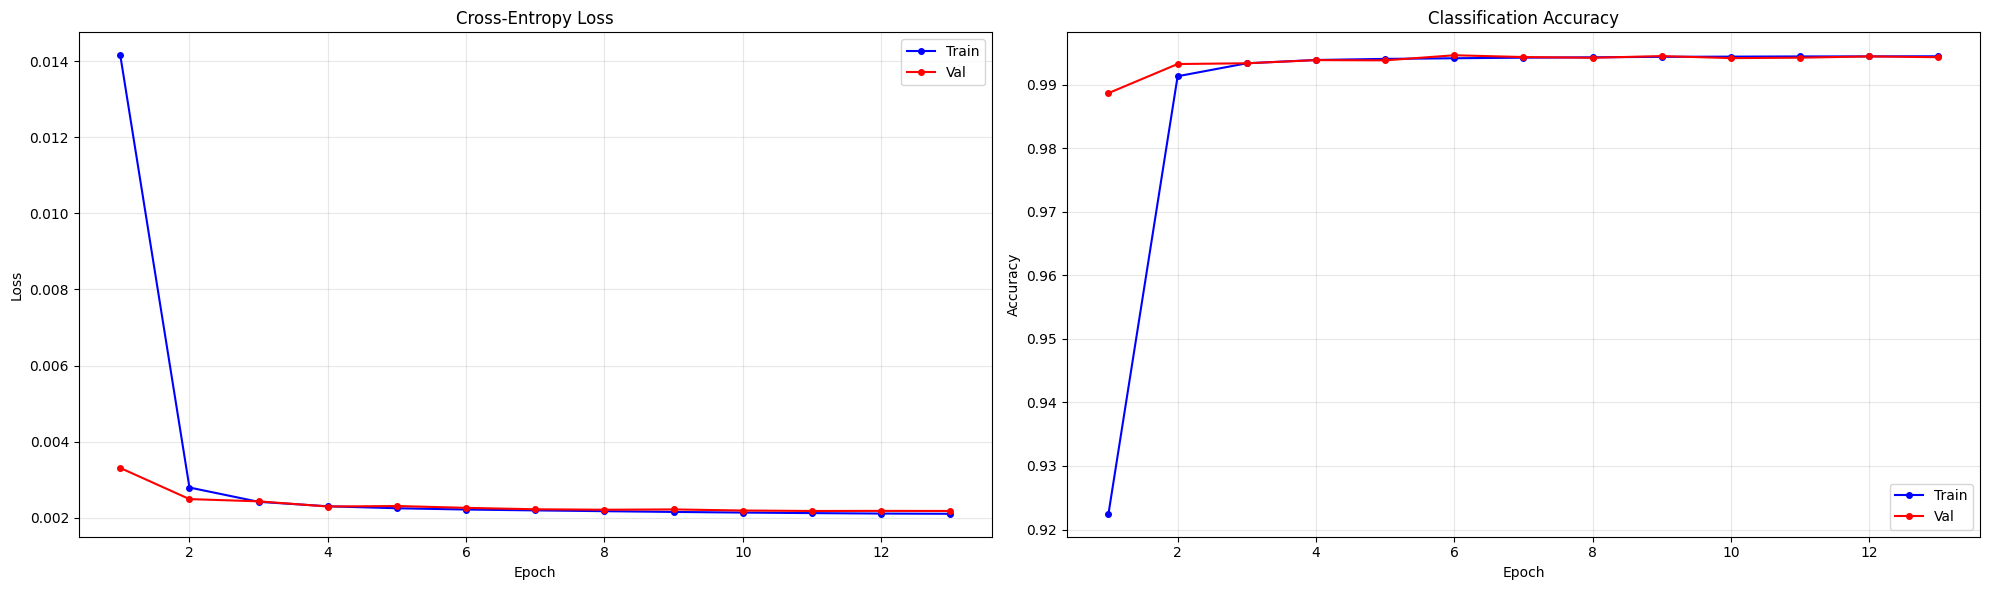

In [22]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
epochs = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs, train_losses, 'b-o', label='Train', markersize=4)
ax1.plot(epochs, val_losses, 'r-o', label='Val', markersize=4)
ax1.set(xlabel='Epoch', ylabel='Loss', title='Cross-Entropy Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, train_accs, 'b-o', label='Train', markersize=4)
ax2.plot(epochs, val_accs, 'r-o', label='Val', markersize=4)
ax2.set(xlabel='Epoch', ylabel='Accuracy', title='Classification Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Next Steps

- Train for d=3 and d=7 by changing `DISTANCE` above and re-running.
- Proceed to **03_evaluation.ipynb** for MWPM comparison and threshold analysis.
- Experiment with model size, learning rate, or training noise rates.